# Explore GRS images

## Load python libraries

In [109]:

import glob
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # activate the rio accessor
from shapely.geometry import box
import datetime as dt

import hvplot.xarray
import pyproj as ppj

#import cartopy
import cartopy.crs as ccrs
#import cartopy.feature as cfeature
#import locale
#locale.setlocale(locale.LC_ALL, 'en_US.utf8')
import matplotlib.pyplot as plt
import matplotlib as mpl
#mpl.use('TkAgg')


plt.rcParams.update({'font.family': 'Times New Roman',
                     'font.size': 16, 'axes.labelsize': 18,

                     })

rc = {"font.family" : "serif",
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

import panel as pn

import grs
import grstbx
from grstbx import visual

from aeronet_visu import data_loading as dl

u = grstbx.utils
opj = os.path.join


print(f'-grs: {grs.__version__}')
print(f'-grstbx: {grstbx.__version__}')

-grs: 2.2.1
-grstbx: 2.0.2


## AERONET-OC data base

In [7]:
sites = ['Abu_Al_Bukhoosh', 'ARIAKE_TOWER', 'Bahia_Blanca', 'Banana_River',
       'Bari_Waterfront', 'Blyth_NOAH', 'Casablanca_Platform',
       'Chesapeake_Bay', 'COVE_SEAPRISM', 'Gageocho_Station',
       'Galata_Platform', 'Gloria', 'Gotland', 'GOT_Seaprism', 'Grizzly_Bay',
       'Gustav_Dalen_Tower', 'HBOI', 'Helsinki_Lighthouse', 'Ieodo_Station',
       'Irbe_Lighthouse', 'KAUST_Campus', 'Kemigawa_Offshore', 'Lake_Erie',
       'Lake_Okeechobee', 'Lake_Okeechobee_N', 'LISCO', 'Lucinda', 'MVCO',
       'Palgrunden', 'PLOCAN_Tower', 'RdP-EsNM', 'Sacramento_River',
       'San_Marco_Platform', 'Section-7_Platform', 'Socheongcho',
       'South_Greenbay', 'Thornton_C-power', 'USC_SEAPRISM', 'USC_SEAPRISM_2',
       'Venise', 'WaveCIS_Site_CSI_6', 'Zeebrugge-MOW1']

idir = '/DATA/AERONET/OCv3/'
odir = '/DATA/AERONET/netcdf/OCv3/'
figdir= '/DATA/AERONET/fig'
level = 'lev20'
for aeronet_site in  sites[0:2]:
    file = aeronet_site+'_OCv3.'+level
    ofile=opj(odir,level,file+'.nc')
    #if os.path.exists(ofile):
    #    continue
    irr = dl.irradiance()
    irr.load_F0()
    
    # ---------------------------------------------
    # Load data and convert into xarray
    # ---------------------------------------------
    try:
        df = dl.read(opj(idir, file)).read_aeronet_ocv3()
    except:
        continue
    
    df = df.droplevel(0, 1)
    # criteria to select scalar and spectrum values
    criteria = df.columns.get_level_values(1) == ''
    df_att = df.loc[:, criteria].droplevel(1, 1)
    df_spec = df.loc[:, ~criteria]
    
    ds = df_spec.stack().to_xarray()
    ds = xr.merge([ds, df_att.to_xarray()])
    #del df
    
    ds = ds.assign_coords({'level_1': ds.level_1.astype(float)}).rename({'level_1': "wl"})
    ds['SZA'] = ds.Solar_Zenith_Angle.mean(axis=1)
    ds['year']=ds['date.year']
    ds['season']=ds['date.season']
    ds = ds.rename_dims({'date':'time'}).rename_vars({'date':'time'})
    # remove bad character (e.g. separtor as ""/"")
    for key in ds.keys():
        if '/' in key:
            ds =ds.rename_vars({key:key.replace('/','')})
    wl = ds.wavelength * 1000
    for param in ['Lw','Lwn','Lwn_IOP','Lwn_fQ']:
        ds['Rrs_'+param] = ds[param] / (irr.get_F0(wl) * 0.1)
    ds.to_netcdf(opj(odir,level,file+'.nc'))

/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/aeronet_visu/data_loading.py:30: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(ifile, skiprows=skiprows, na_values=['N/A', -999.0,-9.999999 ], parse_dates={'date': [1, 2]},
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/aeronet_visu/data_loading.py:30: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(ifile, skiprows=skiprows, na_values=['N/A', -999.0,-9.999999 ], parse_dates={'date': [1, 2]},
/tmp/ipykernel_550906/4174089268.py:39: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify fu

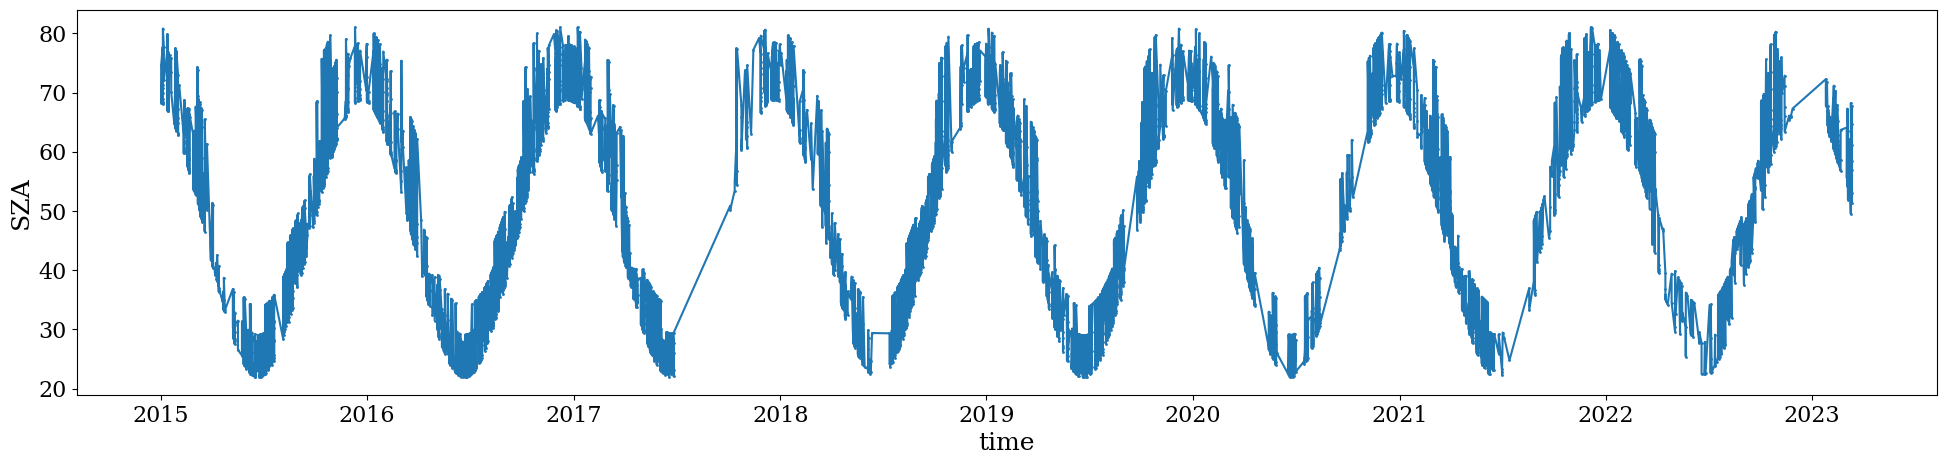

In [6]:
plt.figure(figsize=(24,5))
#dc.datacube.mean_solar_azimuth.plot()
ds.SZA.plot(marker="o",ms=1,label='SZA (deg)')

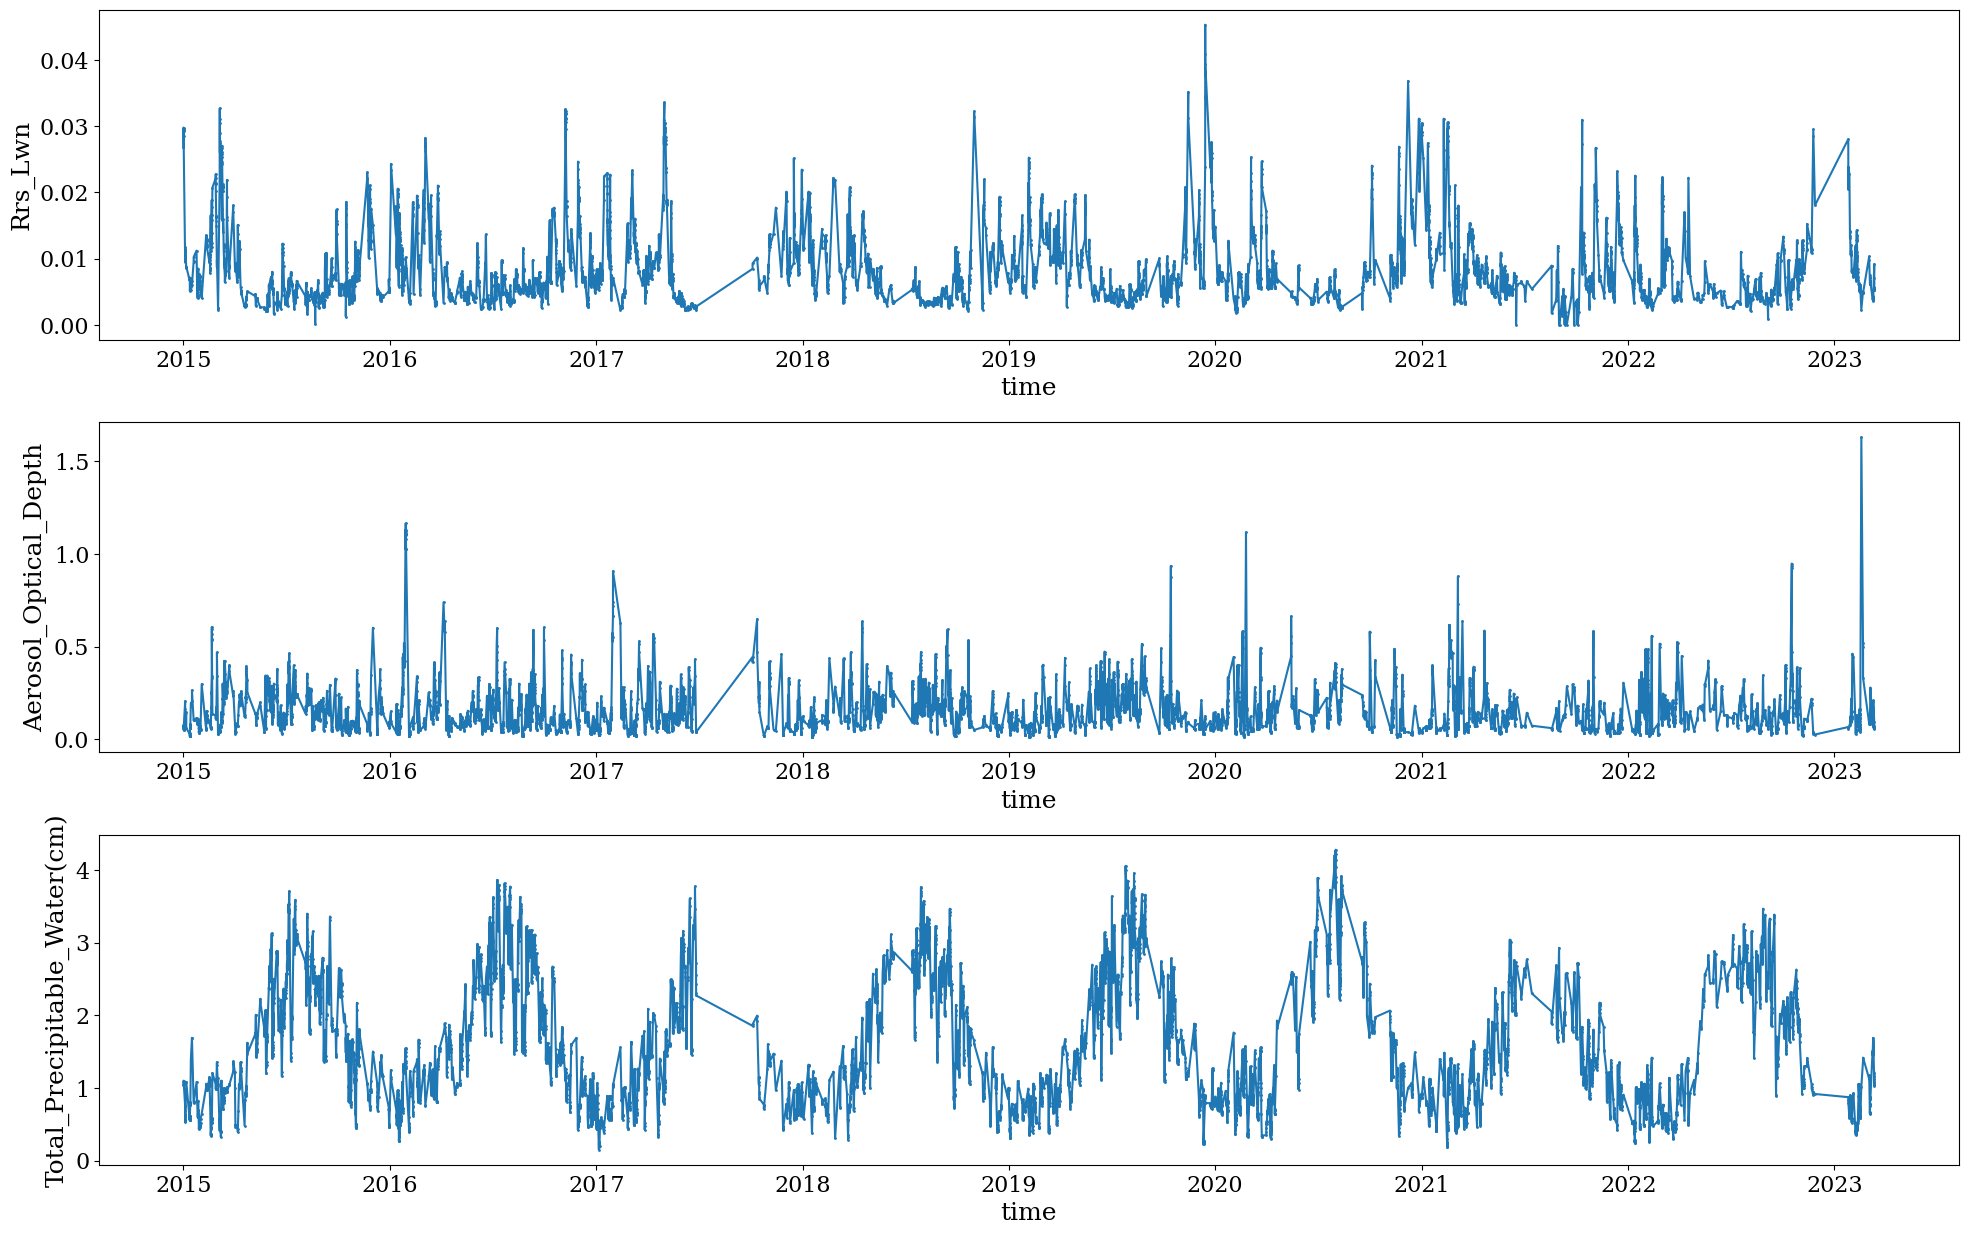

In [22]:
fig, axs = plt.subplots(ncols=1,nrows=3, figsize=(24, 15))
fig.subplots_adjust(hspace=0.25, wspace=0.25)
ds.Rrs_Lwn.sel(wl=550,method='nearest').plot(marker="o",ms=1,ax=axs[0])
ds.Aerosol_Optical_Depth.sel(wl=550,method='nearest').plot(marker="o",ms=1,ax=axs[1])
ds['Total_Precipitable_Water(cm)'].plot(marker="o",ms=1,ax=axs[2])
#dc.datacube.mean_solar_azimuth.plot()
for ax in axs:
    ax.set_title('')

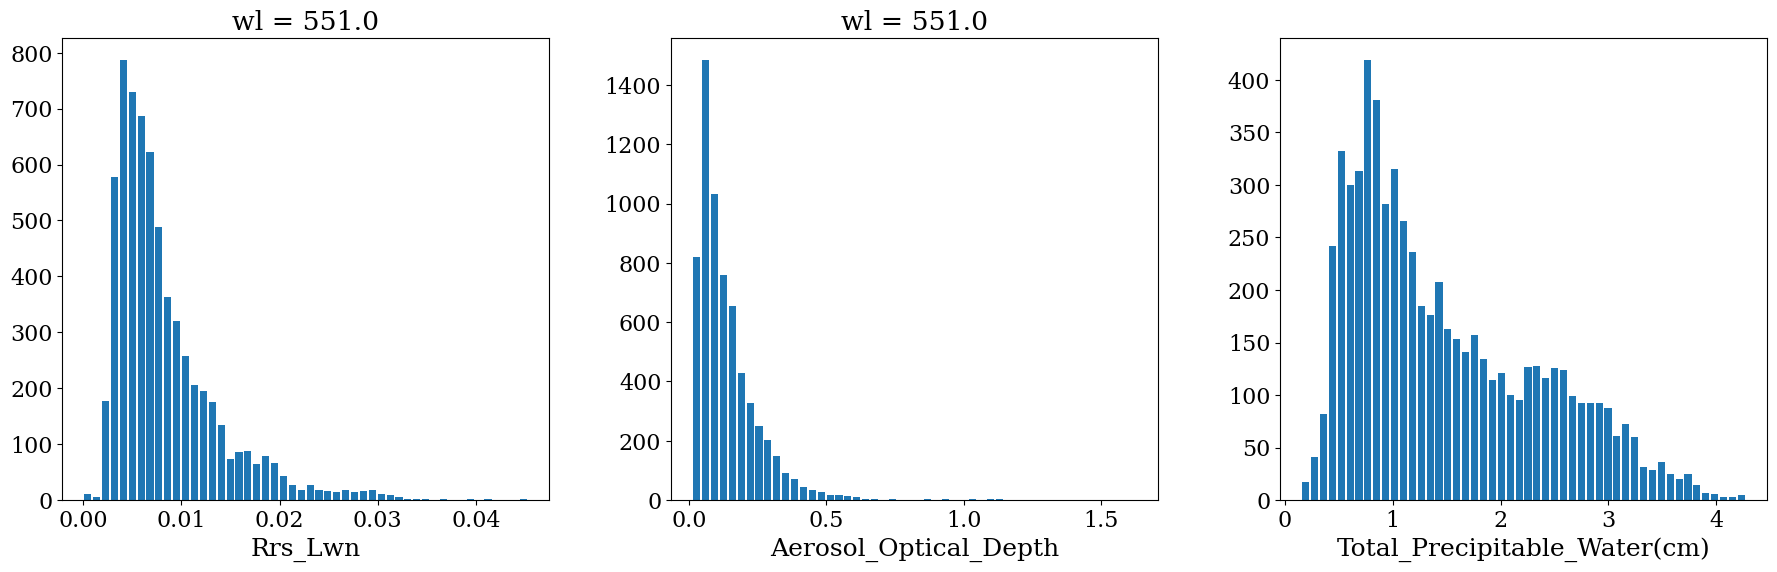

In [17]:
fig, axs = plt.subplots(ncols=3,nrows=1, figsize=(22, 6))
fig.subplots_adjust(hspace=0.05, wspace=0.25)
#dc.datacube.mean_solar_azimuth.plot()
ds.Rrs_Lwn.sel(wl=550,method='nearest').plot.hist(bins=50,rwidth=0.8,ax=axs[0])
ds.Aerosol_Optical_Depth.sel(wl=550,method='nearest').plot.hist(bins=50,rwidth=0.8,ax=axs[1])
ds['Total_Precipitable_Water(cm)'].plot.hist(bins=50,ax=axs[2],rwidth=0.8)

plt.show()

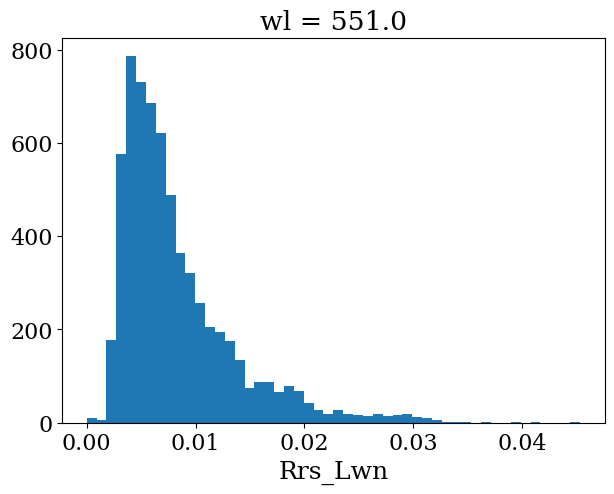

In [12]:
plt.figure(figsize=(7,5))
#dc.datacube.mean_solar_azimuth.plot()
ds.Rrs_Lwn.sel(wl=550,method='nearest').plot.hist(bins=50)
plt.show()

## AERONET aerosol data base

In [134]:
sites = ['Abu_Al_Bukhoosh', 'ARIAKE_TOWER', 'Bahia_Blanca', 'Banana_River',
       'Bari_Waterfront', 'Blyth_NOAH', 'Casablanca_Platform',
       'Chesapeake_Bay', 'COVE_SEAPRISM', 'Gageocho_Station',
       'Galata_Platform', 'Gloria', 'Gotland', 'GOT_Seaprism', 'Grizzly_Bay',
       'Gustav_Dalen_Tower', 'HBOI', 'Helsinki_Lighthouse', 'Ieodo_Station',
       'Irbe_Lighthouse', 'KAUST_Campus', 'Kemigawa_Offshore', 'Lake_Erie',
       'Lake_Okeechobee', 'Lake_Okeechobee_N', 'LISCO', 'Lucinda', 'MVCO',
       'Palgrunden', 'PLOCAN_Tower', 'RdP-EsNM', 'Sacramento_River',
       'San_Marco_Platform', 'Section-7_Platform', 'Socheongcho',
       'South_Greenbay', 'Thornton_C-power', 'USC_SEAPRISM', 'USC_SEAPRISM_2',
       'Venise', 'WaveCIS_Site_CSI_6', 'Zeebrugge-MOW1']

idir = '/DATA/AERONET/V3/'
odir = '/DATA/AERONET/netcdf/V3/'
figdir= '/DATA/AERONET/fig'
level = 'lev20'

aeronet_site = 'Galata_Platform' # 'LISCO' # 'Venise'
file = aeronet_site+'_aod_V3.'+level
ofile=opj(odir,level,file+'.nc')
#if os.path.exists(ofile):
#    continue


# ---------------------------------------------
# Load data and convert into xarray
# ---------------------------------------------
#df = dl.read(opj(idir, file)).read_aeronet()
skiprows=6
ifile = opj(idir, file)
df = pd.read_csv(ifile, skiprows=skiprows, nrows=1)  # read just first line for columns
columns = df.columns.tolist()  # get the columns
cols_to_use = columns[:len(columns) - 1]  # drop the last one
df = pd.read_csv(ifile, skiprows=skiprows, usecols=cols_to_use, index_col=False, na_values=['N/A', -999.0])
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')
df.rename(columns={'AERONET_Site_Name': 'site', 'Last_Processing_Date(dd/mm/yyyy)': 'Last_Processing_Date'},
      inplace=True)
format = "%d:%m:%Y %H:%M:%S"
df['date'] = pd.to_datetime(df[df.columns[0]] + ' ' + df[df.columns[1]], format=format)
# df.set_index(['site','date'], inplace=True)
df.set_index('date', inplace=True)
df = df.drop(df.columns[[0, 1]], axis=1)
# cleaning up
df.drop(list(df.filter(regex='Input')), axis=1, inplace=True)
df.drop(list(df.filter(regex='Empty')), axis=1, inplace=True)
df.drop(list(df.filter(regex='Day')), axis=1, inplace=True)

# indexing columns with spectral values
data_type = df.columns.str.replace('AOD.*nm', 'aot', regex=True)
data_type = data_type.str.replace('Exact_Wave.*', 'wavelength', regex=True)
data_type = data_type.str.replace('Triplet.*[0-9]', 'std', regex=True)
data_type = data_type.str.replace(r'^(?!aot|std|wavelength).*$', '', regex=True)
wl_type=df.columns.str.extract(r'(\d+)').T.astype('float').fillna('').values[0]
#wl_type = pd.to_numeric(h2, errors='coerce')
wl_type = wl_type#.T.values
tuples = list(zip(df.columns, data_type, wl_type))
df.columns = pd.MultiIndex.from_tuples(tuples, names=['l0', 'l1', 'l2'])
if 'wavelength' in df.columns.levels[1]:
    df.loc[:, (slice(None), 'wavelength',)] = df.loc[:, (slice(None), 'wavelength')] * 1000  # convert into nm
df

l0,AOD_1020nm,AOD_870nm,AOD_667nm,AOD_551nm,AOD_532nm,AOD_490nm,AOD_443nm,AOD_412nm,Precipitable_Water(cm),Triplet_Variability_1020,...,Last_Date_Processed,Number_of_Wavelengths,Exact_Wavelengths_of_AOD(um)_1020,Exact_Wavelengths_of_AOD(um)_870,Exact_Wavelengths_of_AOD(um)_667,Exact_Wavelengths_of_AOD(um)_551,Exact_Wavelengths_of_AOD(um)_532,Exact_Wavelengths_of_AOD(um)_490,Exact_Wavelengths_of_AOD(um)_443,Exact_Wavelengths_of_AOD(um)_412
l1,aot,aot,aot,aot,aot,aot,aot,aot,,std,...,,,wavelength,wavelength,wavelength,wavelength,wavelength,wavelength,wavelength,wavelength
l2,1020.0,870.0,667.0,551.0,532.0,490.0,443.0,412.0,,1020.0,...,,,1020.0,870.0,667.0,551.0,532.0,490.0,443.0,412.0
date,,,,,,,,,,,,,,,,,,,,,
2014-04-12 08:53:55,0.031415,0.044300,0.081776,0.131542,0.137909,0.155100,0.183201,0.204576,1.319770,0.004823,...,07:12:2017,8,1018.7,869.8,668.4,551.0,530.6,489.2,441.9,412.4
2014-04-12 09:08:59,0.033579,0.047435,0.084202,0.134230,0.139429,0.156878,0.185243,0.206904,1.320078,0.002089,...,07:12:2017,8,1018.7,869.8,668.4,551.0,530.6,489.2,441.9,412.4
2014-04-12 09:13:24,0.036009,0.048165,0.085578,0.136007,0.141704,0.158746,0.187289,0.208877,1.329891,0.004623,...,07:12:2017,8,1018.7,869.8,668.4,551.0,530.6,489.2,441.9,412.4
2014-04-12 09:23:55,0.033499,0.048463,0.083667,0.133032,0.137612,0.154276,0.182892,0.202026,1.313360,0.000787,...,07:12:2017,8,1018.7,869.8,668.4,551.0,530.6,489.2,441.9,412.4
2014-04-12 09:38:55,0.058885,0.074378,0.117381,0.176537,0.181131,0.203335,0.235984,0.259756,1.331142,0.001168,...,07:12:2017,8,1018.7,869.8,668.4,551.0,530.6,489.2,441.9,412.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-11-23 13:17:30,0.045435,0.062435,0.104219,0.150173,0.158842,0.179918,0.216631,0.239501,1.481516,0.000444,...,05:02:2018,8,1020.1,869.4,667.7,551.1,530.4,490.5,442.0,412.5


In [135]:
ifile

'/DATA/AERONET/V3/Galata_Platform_aod_V3.lev20'

In [136]:
df = df.droplevel(0, 1)
# criteria to select scalar and spectrum values
criteria = df.columns.get_level_values(0) == ''
df_att = df.loc[:, criteria].droplevel(1, 1)
df_spec = df.loc[:, ~criteria]

ds = df_spec.stack().to_xarray()
#ds = xr.merge([ds, df_att.to_xarray()])
#del df

ds = ds.rename({'l2': "wl"})
#ds['SZA'] = ds.Solar_Zenith_Angle.mean(axis=1)
ds['year']=ds['date.year']
ds['season']=ds['date.season']
ds = ds.rename_dims({'date':'time'}).rename_vars({'date':'time'})
ds

/tmp/ipykernel_3115627/3974122368.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ds = df_spec.stack().to_xarray()


<xarray.Dataset> Size: 8MB
Dimensions:     (time: 34357, wl: 8)
Coordinates:
  * time        (time) datetime64[ns] 275kB 2014-04-12T08:53:55 ... 2017-11-2...
  * wl          (wl) object 64B 412.0 443.0 490.0 532.0 551.0 667.0 870.0 1020.0
Data variables:
    aot         (time, wl) float64 2MB 0.2046 0.1832 0.1551 ... 0.07246 0.05262
    std         (time, wl) float64 2MB 0.002898 0.003921 ... 0.00075 0.000755
    wavelength  (time, wl) float64 2MB 412.4 441.9 489.2 ... 869.4 1.02e+03
    year        (time) int64 275kB 2014 2014 2014 2014 ... 2017 2017 2017 2017
    season      (time) <U3 412kB 'MAM' 'MAM' 'MAM' 'MAM' ... 'SON' 'SON' 'SON'

In [137]:
df3 =df_spec.stack()#..to_xarray()
ds = df3.loc[~df3.index.duplicated(keep='first'), :].to_xarray()
ds = ds.rename({'l2': "wl"})
#ds['SZA'] = ds.Solar_Zenith_Angle.mean(axis=1)
ds['year']=ds['date.year']
ds['season']=ds['date.season']
ds = ds.rename_dims({'date':'time'}).rename_vars({'date':'time'})
ds

/tmp/ipykernel_3115627/956250052.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df3 =df_spec.stack()#..to_xarray()


<xarray.Dataset> Size: 8MB
Dimensions:     (time: 34357, wl: 8)
Coordinates:
  * time        (time) datetime64[ns] 275kB 2014-04-12T08:53:55 ... 2017-11-2...
  * wl          (wl) object 64B 412.0 443.0 490.0 532.0 551.0 667.0 870.0 1020.0
Data variables:
    aot         (time, wl) float64 2MB 0.2046 0.1832 0.1551 ... 0.07246 0.05262
    std         (time, wl) float64 2MB 0.002898 0.003921 ... 0.00075 0.000755
    wavelength  (time, wl) float64 2MB 412.4 441.9 489.2 ... 869.4 1.02e+03
    year        (time) int64 275kB 2014 2014 2014 2014 ... 2017 2017 2017 2017
    season      (time) <U3 412kB 'MAM' 'MAM' 'MAM' 'MAM' ... 'SON' 'SON' 'SON'

In [138]:

CVaot = ds['std']/ds.aot
CVaot.name='CV'
CVaot = CVaot.where(CVaot >0,np.nan).where(CVaot <0.15,np.nan)
CV_ = CVaot.to_dataframe()


/tmp/ipykernel_3115627/1992814766.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=CV_,x='wl',y='CV',bw_adjust=0.05, cut=0.1, linewidth=1, palette="rainbow")#, native_scale=True


Text(0, 0.5, '$CV\\ of\\ aot$')

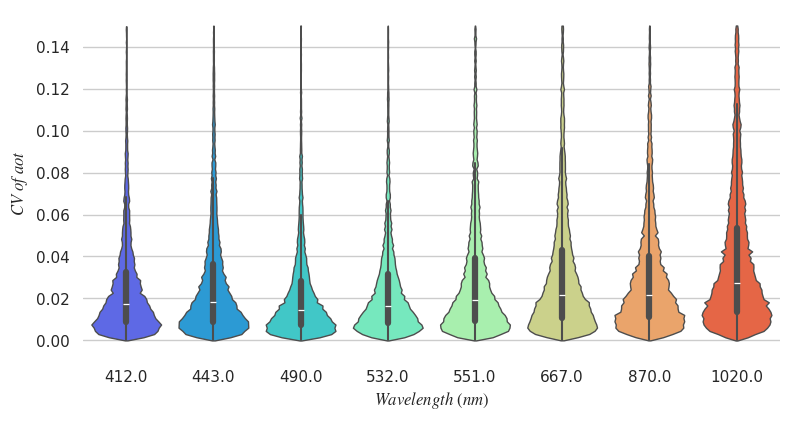

In [139]:

import seaborn as sns
sns.set_theme(style="whitegrid")


# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(9, 4.5))

# Draw a violinplot with a narrower bandwidth than the default
sns.violinplot(data=CV_,x='wl',y='CV',bw_adjust=0.05, cut=0.1, linewidth=1, palette="rainbow")#, native_scale=True

# Finalize the figure
#ax.set(ylim=(-.7, 1.05))
sns.despine(left=True, bottom=True)
ax.set_xlabel(r'$Wavelength\ (nm)$')

#ax.set_ylim(0,0.004)
#ax.set_xlim(650,770)

ax.set_ylabel(r'$CV\ of\ aot$')


In [62]:
ds['year']=ds['date.year']
ds['season']=ds['date.season']
ds = ds.rename_dims({'date':'time'}).rename_vars({'date':'time'})
ds

KeyError: "No variable named 'date.year'. Did you mean one of ('year',)?"

In [59]:
ds

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 15877, wl: 8)
Coordinates:
  * time        (time) datetime64[ns] 127kB 2012-03-01T04:46:00 ... 2016-02-0...
  * wl          (wl) object 64B 412.0 443.0 490.0 532.0 551.0 667.0 870.0 1020.0
Data variables:
    aot         (time, wl) float64 1MB 0.4739 0.4337 0.3844 ... 0.1988 0.1694
    std         (time, wl) float64 1MB 0.01878 0.01211 ... 0.005579 0.004776
    wavelength  (time, wl) float64 1MB 411.8 442.0 489.6 ... 870.8 1.021e+03
    year        (time) int64 127kB 2012 2012 2012 2012 ... 2016 2016 2016 2016
    season      (time) <U3 191kB 'MAM' 'MAM' 'MAM' 'MAM' ... 'DJF' 'DJF' 'DJF'

In [ ]:
sites = ['Abu_Al_Bukhoosh', 'ARIAKE_TOWER', 'Bahia_Blanca', 'Banana_River',
       'Bari_Waterfront', 'Blyth_NOAH', 'Casablanca_Platform',
       'Chesapeake_Bay', 'COVE_SEAPRISM', 'Gageocho_Station',
       'Galata_Platform', 'Gloria', 'Gotland', 'GOT_Seaprism', 'Grizzly_Bay',
       'Gustav_Dalen_Tower', 'HBOI', 'Helsinki_Lighthouse', 'Ieodo_Station',
       'Irbe_Lighthouse', 'KAUST_Campus', 'Kemigawa_Offshore', 'Lake_Erie',
       'Lake_Okeechobee', 'Lake_Okeechobee_N', 'LISCO', 'Lucinda', 'MVCO',
       'Palgrunden', 'PLOCAN_Tower', 'RdP-EsNM', 'Sacramento_River',
       'San_Marco_Platform', 'Section-7_Platform', 'Socheongcho',
       'South_Greenbay', 'Thornton_C-power', 'USC_SEAPRISM', 'USC_SEAPRISM_2',
       'Venise', 'WaveCIS_Site_CSI_6', 'Zeebrugge-MOW1']

idir = '/DATA/AERONET/V3/'
odir = '/DATA/AERONET/netcdf/V3/'
figdir= '/DATA/AERONET/fig'
level = 'lev20'

for aeronet_site in  sites[0:2]:
    file = aeronet_site+'_aod_V3.'+level
    ofile=opj(odir,level,file+'.nc')
    #if os.path.exists(ofile):
    #    continue
  
    
    # ---------------------------------------------
    # Load data and convert into xarray
    # ---------------------------------------------
    try:
        df = dl.read(opj(idir, file)).read_aeronet()
    except:
        continue
    
    df = df.droplevel(0, 1)
    # criteria to select scalar and spectrum values
    criteria = df.columns.get_level_values(1) == ''
    df_att = df.loc[:, criteria].droplevel(1, 1)
    df_spec = df.loc[:, ~criteria]
    
    ds = df_spec.stack().to_xarray()
    ds = xr.merge([ds, df_att.to_xarray()])
    #del df
    
    ds = ds.assign_coords({'level_1': ds.level_1.astype(float)}).rename({'level_1': "wl"})
    ds['SZA'] = ds.Solar_Zenith_Angle.mean(axis=1)
    ds['year']=ds['date.year']
    ds['season']=ds['date.season']
    ds = ds.rename_dims({'date':'time'}).rename_vars({'date':'time'})
    # remove bad character (e.g. separtor as ""/"")
    for key in ds.keys():
        if '/' in key:
            ds =ds.rename_vars({key:key.replace('/','')})
    wl = ds.wavelength * 1000
    for param in ['Lw','Lwn','Lwn_IOP','Lwn_fQ']:
        ds['Rrs_'+param] = ds[param] / (irr.get_F0(wl) * 0.1)
    ds.to_netcdf(opj(odir,level,file+'.nc'))

## Create datacube

In [4]:
rootdir ='/data/satellite/Sentinel-2/L2A/'
dcdir = '/data/satellite/Sentinel-2/datacube/'
tile ='32TQR'
suffix='_matchup2'
start_year,end_year=2018,2023

In [5]:
# subset from center location and width/height
clat=ds['Site_Latitude(Degrees)'].mean()
clon=ds['Site_Longitude(Degrees)'].mean()
height,width=1000,1000

ust = grstbx.SpatioTemp()
box = ust.wktbox(clon, clat, width=width, height=height, ellps='WGS84')
bbox = gpd.GeoSeries.from_wkt([box]).set_crs(epsg=4326)

In [6]:
pattern='*L2A*'
datadir = opj(rootdir, tile, '*', '*', '*', pattern)#,'*[0-9].nc')
list_files = glob.glob(datadir)
list_files
file_labels=['satellite','level','time','baseline','orbit','tile','processing_time']
indexes = ['time','satellite','tile','level','baseline','orbit','processing_time']
basenames = pd.Series([os.path.basename(p) for p in list_files])  # ,columns=['basename']) #basenames
df = basenames.str.split('_', expand=True)
df.columns=file_labels
df['path']=list_files
df['time'] = pd.to_datetime(df['time'])
df=df.set_index(indexes).sort_index(level=0)


In [7]:
start_date='2018-01-01'
end_date='2022-12-31'
files = df[start_date:end_date].values.ravel()
dc_path=opj(dcdir,tile+f'_{start_date}_{end_date}'+suffix+'.nc')
if not os.path.exists(dc_path):
    dc = grstbx.L2grs(files)
    dc.get_l2a_datacube(subset=bbox)
    
    dc.datacube.to_netcdf(dc_path)

In [8]:
dcube=xr.open_dataset(dc_path,decode_coords='all')
dcube

<xarray.Dataset> Size: 30MB
Dimensions:                          (time: 176, wl: 11, y: 35, x: 35)
Coordinates:
  * wl                               (wl) int64 88B 443 490 560 ... 1610 2190
  * time                             (time) datetime64[ns] 1kB 2021-01-08T10:...
  * x                                (x) float64 280B 7.74e+05 ... 7.76e+05
  * y                                (y) float64 280B 5.025e+06 ... 5.023e+06
    central_wavelength               (time, wl) float32 8kB ...
    band                             int64 8B ...
    spatial_ref                      int64 8B ...
Data variables: (12/23)
    Rrs                              (time, wl, y, x) float64 19MB ...
    BRDFg                            (time, y, x) float64 2MB ...
    aot550                           (time, y, x) float64 2MB ...
    mask                             (time, y, x) uint8 216kB ...
    vza                              (time, y, x) float64 2MB ...
    sza                              (time, y, x) float64 2MB ...
    ...                               ...
    flag_opac_cirrus                 (time) float64 1kB ...
    flag_high_swir                   (time) float64 1kB ...
    flag_surfwater_land              (time) float64 1kB ...
    flag_surfwater_water             (time) float64 1kB ...
    flag_surfwater_cloud_and_shadow  (time) float64 1kB ...
    flag_neg_rrs                     (time) float64 1kB ...
Attributes: (12/73)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/32TQR...
    product_name:                        S2B_MSIL1C_20210108T101319_N0500_R02...
    product_filename:                    S2B_MSIL1C_20210108T101319_N0500_R02...
    ...                                  ...
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/Dropbox/Dropbox/work/gi...
    water_vapor_transmittance_file:      /home/harmel/Dropbox/Dropbox/work/gi...
    metadata_profile:                    datacube
    start_date:                          2021-01-08T10:13:19.000000000
    stop_date:                           2023-01-10T10:04:01.000000000

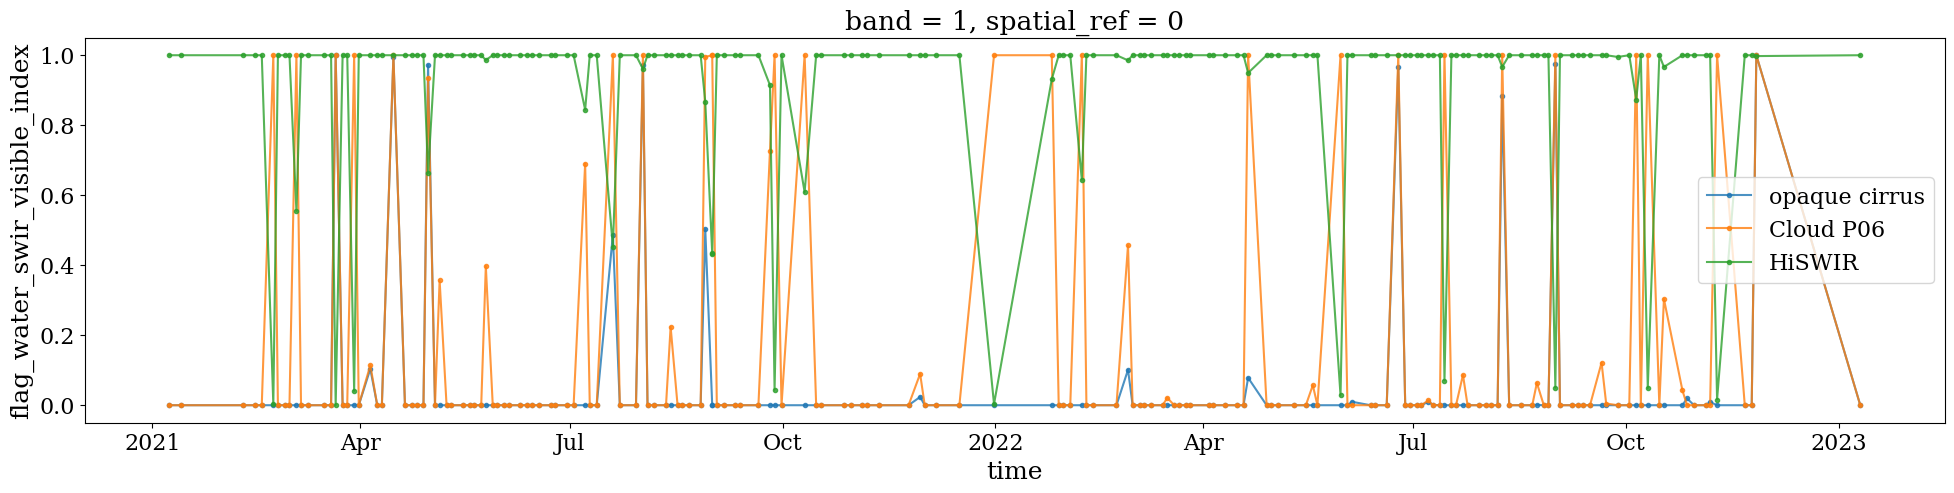

In [9]:

alpha=0.8
plt.figure(figsize=(24,5))
dcube.flag_opac_cirrus.plot(marker="o",ms=3,alpha=alpha,label='opaque cirrus')
dcube.flag_cloud_p06.plot(marker="o",ms=3,alpha=alpha,label='Cloud P06')
dcube.flag_water_swir_visible_index.plot(marker="o",ms=3,alpha=alpha,label='HiSWIR')
plt.legend()

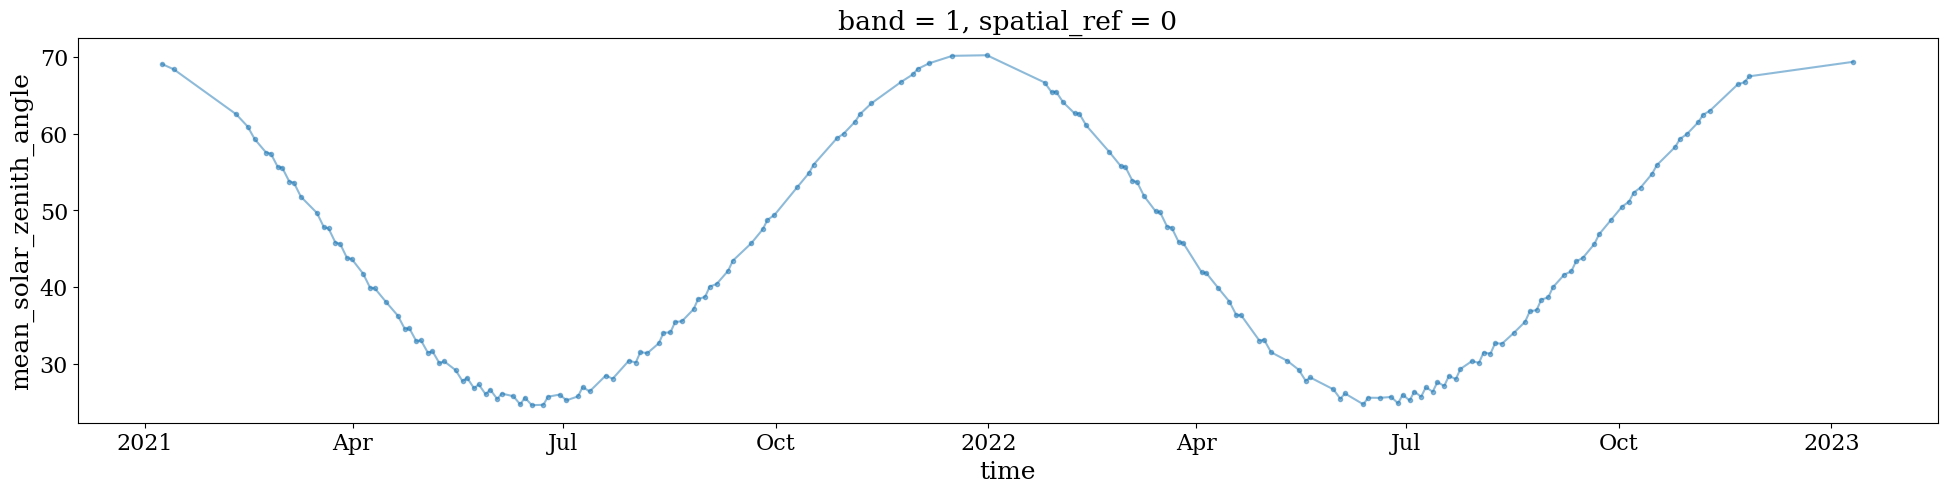

In [66]:
plt.figure(figsize=(24,5))
#dc.datacube.mean_solar_azimuth.plot()
dcube.mean_solar_zenith_angle.plot(marker="o",ms=3,alpha=alpha,label='SZA (deg)')



In [4]:
#xr.concat([dc1.load(),dc2.load()],dim='time')
dc1

<xarray.Dataset>
Dimensions:                          (time: 25, wl: 11, y: 1669, x: 1843)
Coordinates:
  * wl                               (wl) int64 443 490 560 ... 865 1610 2190
  * time                             (time) datetime64[ns] 2018-01-02T10:24:2...
  * x                                (x) float64 7.376e+05 ... 7.744e+05
  * y                                (y) float64 1.3e+06 1.3e+06 ... 1.267e+06
    central_wavelength               (time, wl) float32 ...
    band                             int64 ...
    spatial_ref                      int64 ...
Data variables: (12/23)
    Rrs                              (time, wl, y, x) float32 ...
    BRDFg                            (time, y, x) float32 ...
    aot550                           (time, y, x) float32 ...
    mask                             (time, y, x) uint8 ...
    vza                              (time, y, x) float32 ...
    sza                              (time, y, x) float32 ...
    ...                               ...
    flag_opac_cirrus                 (time) float64 ...
    flag_high_swir                   (time) float64 ...
    flag_surfwater_land              (time) float64 ...
    flag_surfwater_water             (time) float64 ...
    flag_surfwater_cloud_and_shadow  (time) float64 ...
    flag_neg_rrs                     (time) float64 ...
Attributes: (12/74)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/30PYT...
    product_name:                        S2A_MSIL1C_20180102T102421_N0500_R06...
    product_filename:                    S2A_MSIL1C_20180102T102421_N0500_R06...
    ...                                  ...
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/Dropbox/Dropbox/work/gi...
    water_vapor_transmittance_file:      /home/harmel/Dropbox/Dropbox/work/gi...
    metadata_profile:                    datacube
    start_date:                          2018-01-02T10:24:21.000000000
    stop_date:                           2019-01-07T10:24:11.000000000